In [3]:
from sklearn.cluster import KMeans
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
%matplotlib inline

In [4]:
df= pd.read_csv("income.csv")
df.head()

,Name,Age,Income($)
0,Rob,27,70000
1,Michael,29,90000
2,Mohan,29,61000
3,Ismail,28,60000
4,Kory,42,150000


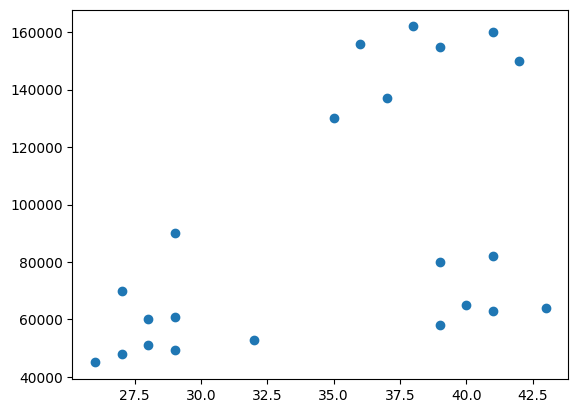

In [5]:
plt.scatter(df["Age"], df["Income($)"])

In [6]:
km= KMeans(n_clusters=3)
km

KMeans(n_clusters=3)

In [7]:
y_predicted= km.fit_predict(df[["Age", "Income($)"]])
y_predicted

array([1, 2, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 1],
      dtype=int32)

In [8]:
df["cluter"]= y_predicted
df.head()

,Name,Age,Income($),cluter
0,Rob,27,70000,1
1,Michael,29,90000,2
2,Mohan,29,61000,1
3,Ismail,28,60000,1
4,Kory,42,150000,0


C:\Users\Niloy\AppData\Local\Temp\ipykernel_29808\212135516.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


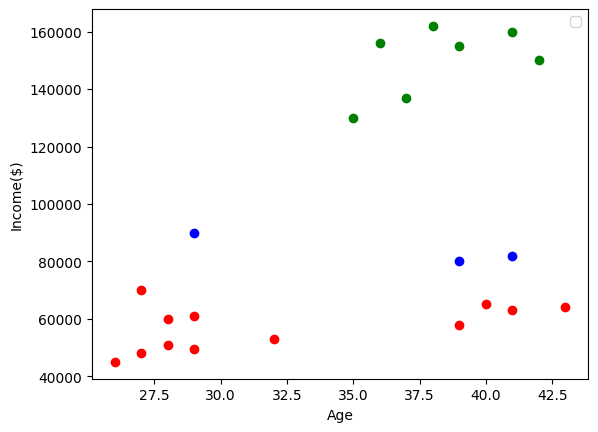

In [9]:
df1= df[df.cluter==0]
df2= df[df.cluter==1]
df3= df[df.cluter==2]
plt.scatter(df1["Age"], df1["Income($)"], color="green")
plt.scatter(df2["Age"], df2["Income($)"], color="red")
plt.scatter(df3["Age"], df3["Income($)"], color="blue")
plt.xlabel("Age")
plt.ylabel("Income($)")
plt.legend()

In [10]:
scaler = MinMaxScaler()

scaler.fit(df[['Income($)']])
df['Income($)'] = scaler.transform(df[['Income($)']])

scaler.fit(df[['Age']])
df['Age'] = scaler.transform(df[['Age']])
df.head()

,Name,Age,Income($),cluter
0,Rob,0.058824,0.213675,1
1,Michael,0.176471,0.384615,2
2,Mohan,0.176471,0.136752,1
3,Ismail,0.117647,0.128205,1
4,Kory,0.941176,0.897436,0


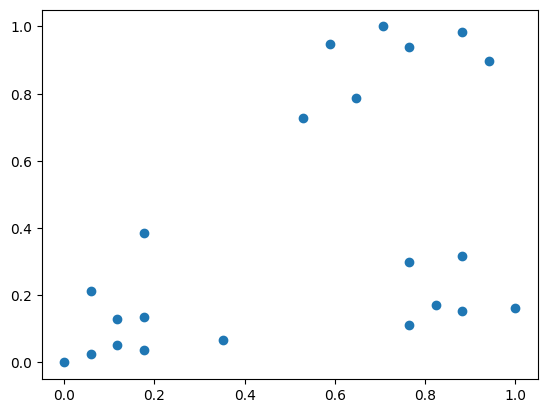

In [11]:
plt.scatter(df.Age,df['Income($)'])

In [12]:
km1= KMeans(n_clusters=3)
y_predicted1= km1.fit_predict(df[["Age", "Income($)"]])
y_predicted1

array([0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 2, 2, 2, 2, 2, 2],
      dtype=int32)

In [13]:
df["Cluster"]= y_predicted1

df

,Name,Age,Income($),cluter,Cluster
0,Rob,0.058824,0.213675,1,0
1,Michael,0.176471,0.384615,2,0
2,Mohan,0.176471,0.136752,1,0
3,Ismail,0.117647,0.128205,1,0
4,Kory,0.941176,0.897436,0,1
5,Gautam,0.764706,0.940171,0,1
6,David,0.882353,0.982906,0,1
7,Andrea,0.705882,1.000000,0,1
8,Brad,0.588235,0.948718,0,1
9,Angelina,0.529412,0.726496,0,1


C:\Users\Niloy\AppData\Local\Temp\ipykernel_29808\2424790544.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


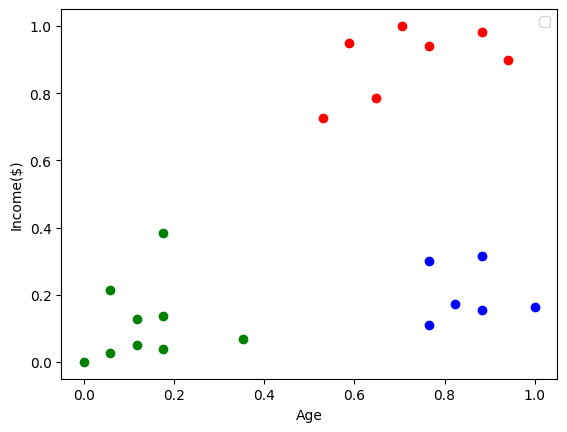

In [14]:
df4= df[df.Cluster==0]
df5= df[df.Cluster==1]
df6= df[df.Cluster==2]
plt.scatter(df4["Age"], df4["Income($)"], color="green")
plt.scatter(df5["Age"], df5["Income($)"], color="red")
plt.scatter(df6["Age"], df6["Income($)"], color="blue")
plt.xlabel("Age")
plt.ylabel("Income($)")
plt.legend()


In [15]:
sse= []
k_rng= range(1, 10)
for k in k_rng:
    km= KMeans(n_clusters=k)
    km.fit(df[["Age", "Income($)"]])
    sse.append(km.inertia_)

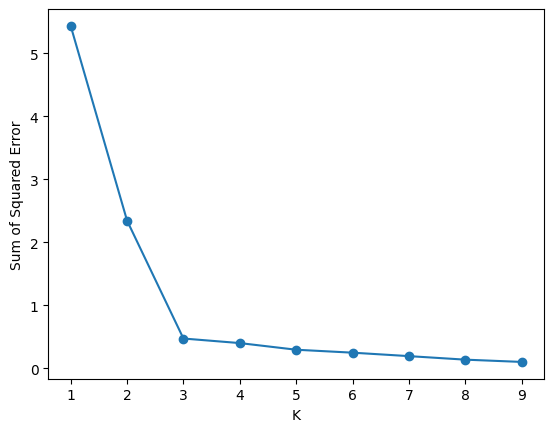

In [16]:
plt.xlabel("K")
plt.ylabel("Sum of Squared Error")
plt.plot(k_rng, sse, marker='o')

In [33]:
from sklearn.datasets import load_iris
iris = load_iris()
iris_df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
iris_df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [34]:
iris_df.drop(['sepal length (cm)', 'sepal width (cm)'], axis=1, inplace=True)
iris_df.head()

,petal length (cm),petal width (cm)
0,1.4,0.2
1,1.4,0.2
2,1.3,0.2
3,1.5,0.2
4,1.4,0.2


In [36]:
iris_df["flower"]= iris.target
iris_df.head()

,petal length (cm),petal width (cm),flower
0,1.4,0.2,0
1,1.4,0.2,0
2,1.3,0.2,0
3,1.5,0.2,0
4,1.4,0.2,0


In [38]:
iris_df.drop(['flower'], axis=1, inplace=True)
iris_df.head()

,petal length (cm),petal width (cm)
0,1.4,0.2
1,1.4,0.2
2,1.3,0.2
3,1.5,0.2
4,1.4,0.2


In [39]:
km_iris = KMeans(n_clusters=3)
y_predicted_iris = km_iris.fit_predict(iris_df)
y_predicted_iris

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 2, 2, 2, 2, 0, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 2, 2, 0, 2, 2, 0, 0, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2], dtype=int32)

In [42]:
km_iris.predict([[5.1, 1.5]])

c:\Users\Niloy\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


array([2], dtype=int32)

In [40]:
iris_df["cluster"]= y_predicted_iris
iris_df.head()

,petal length (cm),petal width (cm),cluster
0,1.4,0.2,1
1,1.4,0.2,1
2,1.3,0.2,1
3,1.5,0.2,1
4,1.4,0.2,1


C:\Users\Niloy\AppData\Local\Temp\ipykernel_29808\274371478.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


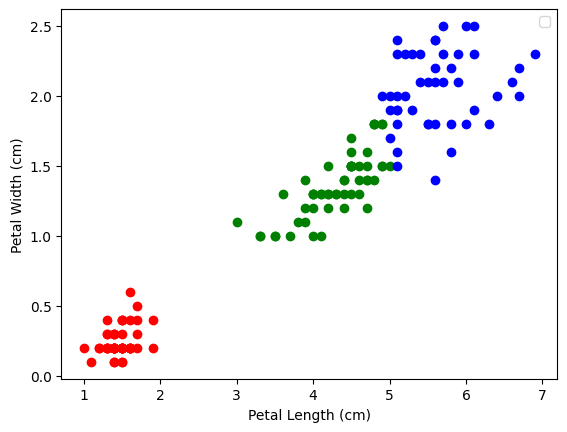

In [41]:
df7= iris_df[iris_df.cluster==0]
df8= iris_df[iris_df.cluster==1]
df9= iris_df[iris_df.cluster==2]
plt.scatter(df7["petal length (cm)"], df7["petal width (cm)"], color="green")
plt.scatter(df8["petal length (cm)"], df8["petal width (cm)"], color="red")
plt.scatter(df9["petal length (cm)"], df9["petal width (cm)"], color="blue")
plt.xlabel("Petal Length (cm)")
plt.ylabel("Petal Width (cm)") 
plt.legend()

In [44]:
sse_iris = []
k_rng_iris = range(1, 10)
for k in k_rng_iris:
    km_iris = KMeans(n_clusters=k)
    km_iris.fit(iris_df)
    sse_iris.append(km_iris.inertia_)
sse_iris    


[650.4686666666665,
 185.8756625074272,
 31.412885668276974,
 22.222713554987212,
 14.168006701631702,
 11.953318452380955,
 10.325653439153442,
 8.806816526610646,
 7.530212956634011]

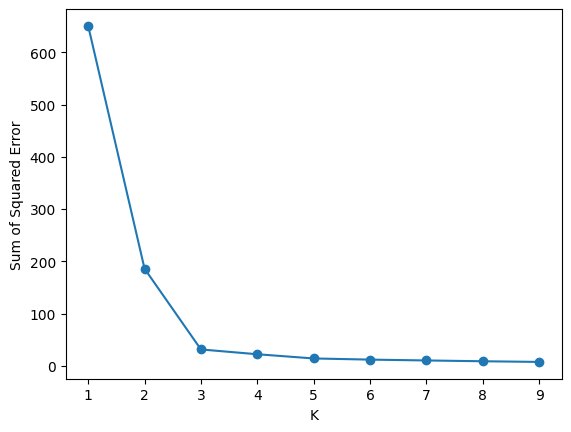

: 

In [ ]:
plt.xlabel("K")
plt.ylabel("Sum of Squared Error")
plt.plot(k_rng_iris, sse_iris, marker='o')